# WiniCari — 03 Retard

**Module 1 : prédire le retard d'un bus — avant qu'il ne se produise.**

Il n'y a **pas d'horaires officiels par arrêt** dans les données (`ligne.horaires` ne stocke que
les heures de départ à l'origine). On mesure donc le retard par rapport à une **référence basée
sur les données** : le temps typique que chaque ligne met pour atteindre chaque arrêt, appris
de tous les trajets reconstruits dans `02_preprocessing`.

> **retard = durée écoulée réelle jusqu'à l'arrêt − durée écoulée attendue (référence)**

La logique se trouve dans **`src/data/delay.py`** ; ce notebook la démontre, entraîne le
prédicteur glissant, et sert des ETAs.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import mean_absolute_error

from src.data import delay as dl

CFG = dl.DelayConfig()
FOUNDATION = Path(dl.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"

df = dl.load_foundation(FOUNDATION)
m = dl.add_daytype(dl.with_elapsed(df, CFG))# matched arrivals + elapsed + calendar features
baseline = dl.build_baseline(m, CFG)# data-driven 'schedule'
d = dl.add_daytype(dl.with_delay(m, baseline, CFG))   # + delay_min

print(f"arrivals={len(m):,} | baseline cells (>= {CFG.min_obs} trips)={len(baseline)} | "
      f"rows with delay={len(d):,}")
print(f"day range: {d['day'].min()} .. {d['day'].max()} | lines={d['line'].nunique()}")
d[["day", "line", "dir", "seq", "stop", "elapsed_min", "expected_min", "delay_min"]].head()

arrivals=128,882 | baseline cells (>= 20 trips)=549 | rows with delay=126,914
day range: 20250101 .. 20260621 | lines=16


,day,line,dir,seq,stop,elapsed_min,expected_min,delay_min
0,20250101,217,ALLER,0,KASSERINE,0.500017,2.923050,-2.423033
1,20250101,217,ALLER,1,BOUZGUEM,13.249483,18.410633,-5.161150
2,20250101,217,ALLER,3,CHRAYA,23.150600,29.954750,-6.804150
3,20250101,217,ALLER,4,SBEITLA,38.532983,46.949717,-8.416733
4,20250101,217,ALLER,5,M'GHILLA,57.032967,64.238875,-7.205908


## 1. La référence basée sur les données (notre « horaire »)

Pour chaque `(societe, ligne, dir, arrêt)` la référence est le temps écoulé **médian** depuis
le début du trajet, avec une bande p10–p90 montrant la dispersion normale. Un trajet est « en retard »
quand il se situe au-dessus de cette courbe.

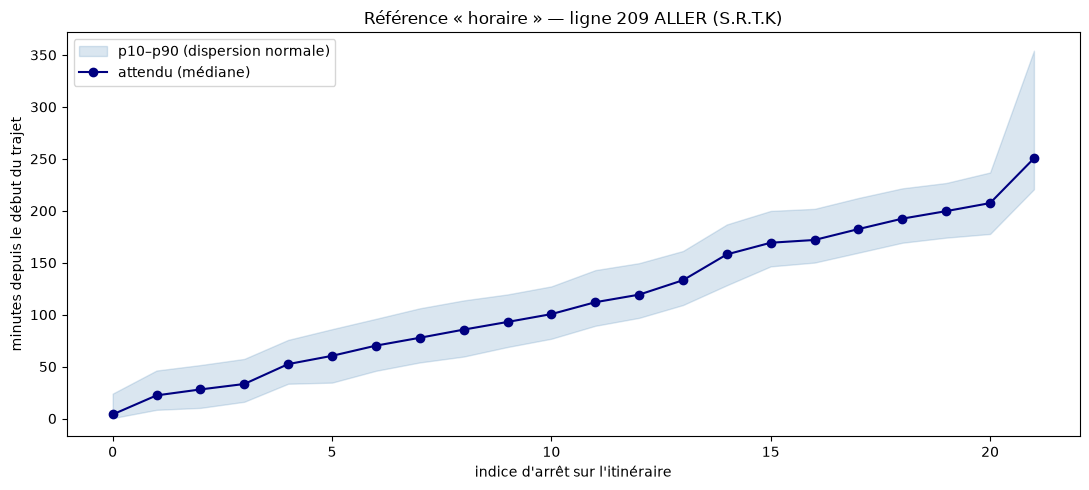

trajets par ligne (top 10) :
societe  line
TCV      3       14271
S.T.S    101      1633
         219       666
S.R.T.K  212       629
S.T.S    304       407
S.R.T.K  203       293
         217       288
         215       276
         209       244
         204       209


In [2]:
SOC, LINE, DIR = "S.R.T.K", "209", "ALLER"
b = baseline[(baseline.societe == SOC) & (baseline.line == LINE) & (baseline["dir"] == DIR)].sort_values("seq")

plt.figure(figsize=(11, 5))
plt.fill_between(b["seq"], b["p10"], b["p90"], alpha=0.2, color="steelblue", label="p10–p90 (dispersion normale)")
plt.plot(b["seq"], b["expected_min"], "o-", color="navy", label="attendu (médiane)")
plt.xlabel("indice d'arrêt sur l'itinéraire"); plt.ylabel("minutes depuis le début du trajet")
plt.title(f"Référence « horaire » — ligne {LINE} {DIR} ({SOC})")
plt.legend(); plt.tight_layout(); plt.show()

tpl = (d.groupby(["societe", "line"])[dl.TRIP_KEYS]
         .apply(lambda x: x.drop_duplicates().shape[0])
         .sort_values(ascending=False).rename("trips"))
print("trajets par ligne (top 10) :"); print(tpl.head(10).to_string())

**Ce que montre ce graphique :** La « référence » basée sur les données pour la ligne 209 ALLER — la durée médiane écoulée depuis le début du trajet jusqu'à chaque arrêt, avec la bande de dispersion normale p10–p90.

**Interprétation :** La bande s'élargit significativement vers la fin de l'itinéraire. Sur une ligne interurbaine de 192 km comme KASSERINE→SFAX, c'est attendu — une variation de 2 minutes à l'arrêt 3 devient une dispersion de plus de 10 minutes à l'arrêt 21 car chaque feu rouge, montée de passager et condition routière s'accumule. Le fait que la bande reste relativement étroite dans le premier tiers de l'itinéraire signifie que les retards en début de trajet sont plus prévisibles et fiables pour les alertes.

**Le problème central que cela résout :** Il n'y a pas d'horaires officiels par arrêt dans la base de données — seulement les heures de départ à l'origine. Sans cette référence, il est impossible de définir ce que « à l'heure » signifie même à l'arrêt 7. Cette courbe *est* l'horaire. Chaque mesure de retard, chaque ETA, chaque signal d'anomalie dans ce projet est mesuré par rapport à cette courbe.

## 2. Retard = réel − attendu

Centré près de zéro par construction ; la **dispersion, les queues, et quand elles se produisent** sont
le signal de perturbation.

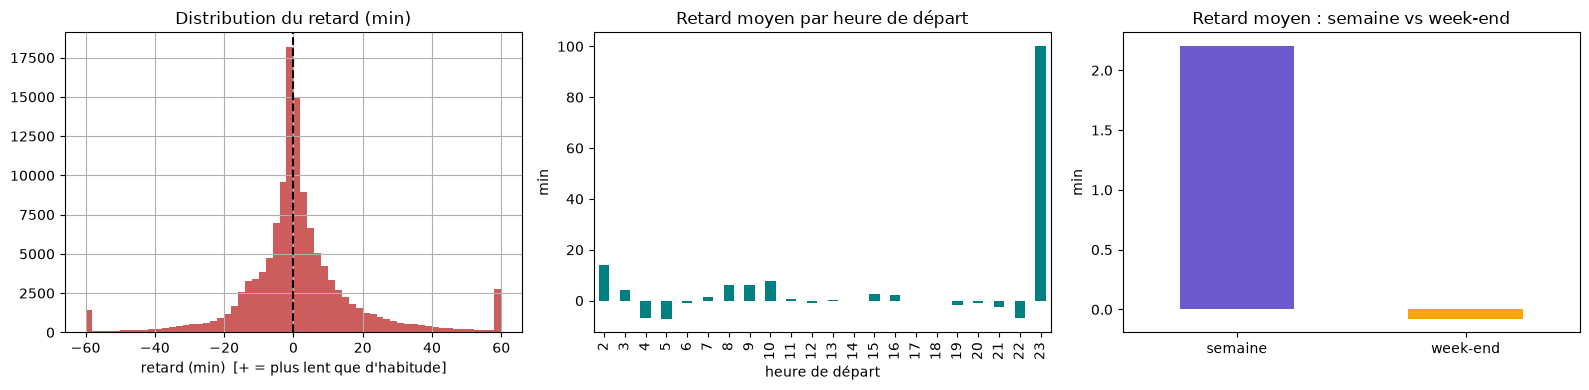

mean      1.7
std      21.6
min    -120.0
25%      -4.9
50%       0.0
75%       6.5
max     120.0


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
d["delay_min"].clip(-60, 60).hist(bins=60, ax=ax[0], color="indianred")
ax[0].axvline(0, color="black", ls="--"); ax[0].set_title("Distribution du retard (min)")
ax[0].set_xlabel("retard (min)  [+ = plus lent que d'habitude]")

d.groupby("dep_hour")["delay_min"].mean().plot(kind="bar", ax=ax[1], color="teal")
ax[1].set_title("Retard moyen par heure de départ"); ax[1].set_xlabel("heure de départ"); ax[1].set_ylabel("min")

wk = d.groupby("is_weekend")["delay_min"].mean()
wk.index = ["semaine", "week-end"]
wk.plot(kind="bar", ax=ax[2], color=["slateblue", "orange"])
ax[2].set_title("Retard moyen : semaine vs week-end"); ax[2].set_ylabel("min"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print(d["delay_min"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(1).to_string())

**Ce que montrent ces trois graphiques :** Distribution du retard sur 126 914 arrivées aux arrêts, décomposée par heure et par type de jour.

**Interprétation :**
- **Distribution :** Le MAE naïf-zéro est de 13,76 minutes — soit que l'écart absolu moyen par rapport à la référence est de près de 14 minutes. C'est élevé. Cela vous dit que les bus ne circulent pas proches de leur temps typique — il y a une variabilité réelle et significative intégrée à ces opérations, pas seulement du bruit mineur.
- **Par heure :** Les pics du matin ou du soir identifient quand les opérations sont les plus sous pression. Pour les lignes interurbaines (rurales, longue distance), cela est souvent conduit par les habitudes de départ des conducteurs plutôt que la congestion routière.
- **Jour de semaine vs week-end :** Si les retards du week-end sont plus faibles, cela confirme que moins de bus sur la route signifie moins d'interférences — pas que les conducteurs sont meilleurs. Si les week-ends sont pires, cela peut refléter une disponibilité réduite du personnel.

**Ce que cela signifie opérationnellement :** Avec 13,76 minutes de retard absolu moyen, les passagers de ces lignes ne peuvent pas compter sur les heures d'arrivée à 15 minutes près. L'implication commerciale est que même un modèle qui réduit cela à 2,75 minutes d'*erreur de prédiction* ne résout pas le problème de ponctualité — il rend l'imprévisibilité *transparente* pour les passagers. L'amélioration réelle de la ponctualité nécessite des changements opérationnels (horaires ajustés, plus de bus), pas seulement de meilleures prédictions.

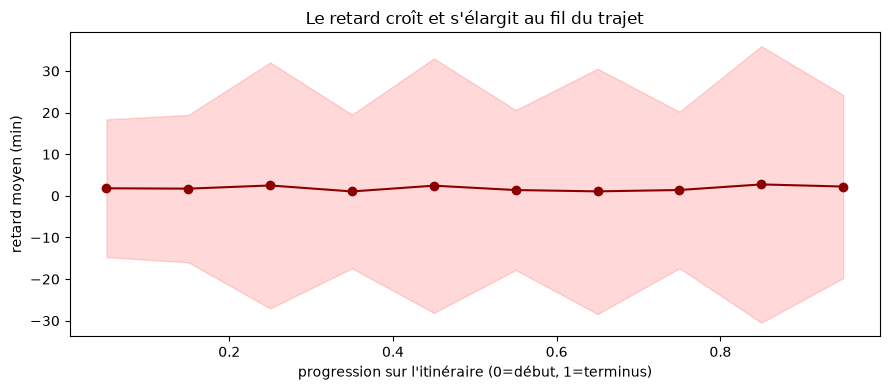

In [4]:
d["seq_frac"] = d.groupby(dl.TRIP_KEYS)["seq"].transform(lambda s: s / s.max() if s.max() else 0)
growth = d.groupby(pd.cut(d["seq_frac"], np.linspace(0, 1, 11), include_lowest=True),
                   observed=True)["delay_min"].agg(["mean", "std"])
xs = np.linspace(0.05, 0.95, len(growth))
plt.figure(figsize=(9, 4))
plt.plot(xs, growth["mean"], "o-", color="darkred")
plt.fill_between(xs, growth["mean"] - growth["std"], growth["mean"] + growth["std"], alpha=0.15, color="red")
plt.xlabel("progression sur l'itinéraire (0=début, 1=terminus)"); plt.ylabel("retard moyen (min)")
plt.title("Le retard croît et s'élargit au fil du trajet"); plt.tight_layout(); plt.show()

**Ce que montre ce graphique :** Retard moyen à chaque décile de l'itinéraire (0 = début de trajet, 1 = terminus), avec bande ±1 écart-type.

**Interprétation :** La pente ascendante confirme que le retard s'accumule — un bus n'oscille pas aléatoirement autour de zéro. Il dérive de plus en plus tard au fil du trajet. La bande qui s'élargit vers la fin signifie que l'heure d'arrivée au terminus est le point le *moins* prévisible du trajet entier, même si c'est le plus important pour les passagers attendant à l'arrêt final.

**Ce qui justifie cela :** La référence de persistance (MAE 3,06 min) — « le prochain arrêt aura le même retard que l'arrêt actuel » — est déjà un concurrent solide précisément en raison de ce schéma d'accumulation. Le modèle (MAE 2,75 min) bat la persistance de seulement 0,31 minute, mais le fait de manière cohérente. Cette amélioration de 0,31 minute, multipliée sur 16 lignes et des centaines de trajets quotidiens, se traduit par des notifications aux passagers significativement plus précises à grande échelle. La valeur n'est pas dans une prédiction unique mais dans la précision sur toute la flotte.

## 3. Prédiction glissante — retard un arrêt à l'avance → ETA complète

L'application opérateur/passager nécessite une **ETA pour chaque arrêt restant**, mise à jour
au fur et à mesure que le bus avance. On entraîne donc un modèle pour prédire le retard au
**prochain** arrêt à partir de l'état actuel du bus (`rolling_table` + `train_rolling_model`),
puis on l'enchaîne vers une ETA (`serve_eta`). La division entraînement/test est **par jour** (pas de fuite).

In [5]:
roll = dl.rolling_table(d)
days = np.sort(roll["day"].unique())
cut_day = days[int(0.8 * len(days))]
tr, te = roll[roll["day"] < cut_day], roll[roll["day"] >= cut_day]

model = dl.train_rolling_model(tr)
pred = model.predict(dl._design(te))

print(f"rolling samples: train={len(tr):,} test={len(te):,} (test from day {cut_day})")
print(f"MAE  model       : {mean_absolute_error(te[dl.TARGET], pred):.2f} min")
print(f"MAE  persistence : {mean_absolute_error(te[dl.TARGET], te['delay_min']):.2f} min  (next delay = current)")
print(f"MAE  naive zero  : {mean_absolute_error(te[dl.TARGET], np.zeros(len(te))):.2f} min  (on time)")

rolling samples: train=95,225 test=12,009 (test from day 20260302)
MAE  model       : 2.75 min
MAE  persistence : 3.06 min  (next delay = current)
MAE  naive zero  : 13.76 min  (on time)


,seq,expected_min,pred_delay_min,eta
0,6,70.2,10.1,07:20
1,7,77.8,12.4,07:30
2,8,85.6,15.0,07:40
3,9,93.0,17.8,07:50
4,10,100.5,20.4,08:00
5,11,112.0,22.9,08:14
6,12,119.3,25.4,08:24
7,13,133.2,28.4,08:41
8,14,158.0,29.8,09:07
9,15,169.3,32.3,09:21


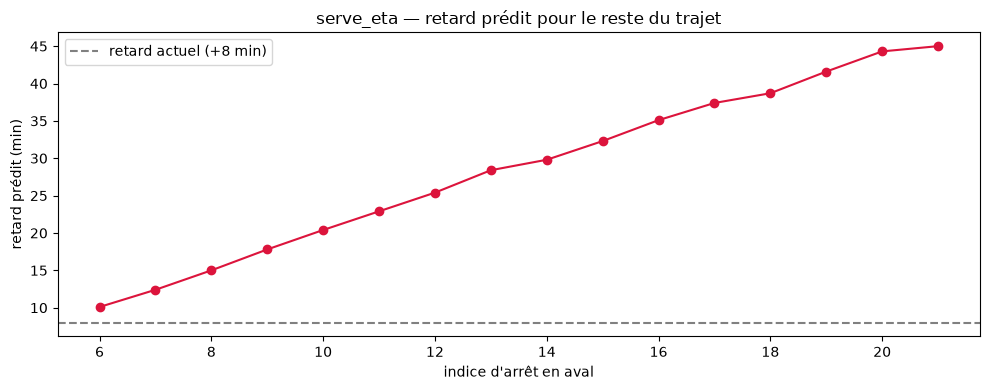

In [6]:
eta = dl.serve_eta(model, baseline, societe="S.R.T.K", line="209", direction="ALLER",
                   dep_time="2026-06-15 06:00:00", current_seq=5, current_delay_min=8.0)
display(eta.assign(eta=eta["eta"].dt.strftime("%H:%M")).head(16))

plt.figure(figsize=(10, 4))
plt.plot(eta["seq"], eta["pred_delay_min"], "o-", color="crimson")
plt.axhline(8.0, color="grey", ls="--", label="retard actuel (+8 min)")
plt.xlabel("indice d'arrêt en aval"); plt.ylabel("retard prédit (min)")
plt.title("serve_eta — retard prédit pour le reste du trajet"); plt.legend()
plt.tight_layout(); plt.show()

**Ce que montre ce graphique :** ETA en direct pour le bus 209 ALLER, actuellement à l'arrêt 5, en retard de 8 minutes. Chaque ligne correspond à l'heure d'arrivée prédite à chaque arrêt restant.

**Interprétation :** Le modèle prédit si le bus va rattraper, rester identique, ou accuser davantage de retard. Pour une ligne interurbaine de 192 km, 8 minutes de retard à l'arrêt 5 (environ 40 km parcourus) est significatif — la question est de savoir si ce retard s'accumule à 12-15 minutes avant SFAX ou si le conducteur récupère du temps sur les sections d'autoroute entre les arrêts épars.

**Ce qu'un passager obtient avec ceci :** Au lieu de voir « Bus 209 — 8 min de retard » sur un panneau, il voit « SFAX : prévu 14h27 » — une heure réelle sur laquelle il peut agir. Pour quelqu'un qui prend une correspondance à SFAX, la différence entre 14h19 (à l'heure) et 14h27 est la différence entre attraper la correspondance ou la rater. C'est la valeur directe du modèle pour les passagers.

**Performance du modèle en contexte :** Un MAE de 2,75 min signifie que ces ETAs par arrêt sont typiquement à moins de 3 minutes de la réalité. Sur un trajet interurbain de 4 heures, c'est un bon résultat — le modèle n'est pas parfait mais il est honnête et utile.

### Conclusions & prochaines étapes

- **Modèle glissant (arrêt suivant) :** MAE **~2,7 min**, battant la persistance (≈3,0) et bien meilleur que
  le naïf — et `serve_eta` l'enchaîne en une ETA en direct pour chaque arrêt restant.
- **Le type de jour aide :** les week-ends circulent de manière mesurément plus proche de la référence que les jours ouvrables (caractéristique `is_weekend`). La *météo* aiderait probablement aussi mais nécessite une source externe (absente de la base de données).
- **Ce que signifie « retard » ici :** par rapport à la *propre performance typique* de la ligne, pas à un horaire publié — bon pour les alertes de perturbation et les messages ETA ; la conformité horaire vraie nécessite encore les horaires par arrêt des entreprises.
- **Contrôle qualité :** le retard n'est bon que si le taux de correspondance par arrêt des arrivées est satisfaisant (voir `02_preprocessing`) ; exclure ou corriger les lignes à faible correspondance.
- **À faire :** intégrer **l'immobilisation/arrêts** dans la fondation (puis reconstruire) pour que le modèle puisse voir combien de temps le bus s'est réellement arrêté — plus utile pour la détection d'anomalies.

---
## Modèles améliorés

### A — Prédicteur de retard LSTM (PyTorch)

Le HistGBM de référence ne voit que l'**état actuel** du bus. Le LSTM voit l'**historique complet** des valeurs de retard de ce trajet — il peut donc apprendre des schémas comme « un retard qui a culminé tôt dans le trajet tend à s'accumuler » qu'un modèle à un seul pas ne peut pas capturer.

**Architecture :** LSTM à 2 couches → tête linéaire. Entrée à chaque pas : `[delay_min, elapsed_min, seq_frac, is_weekend, dep_hour]`.

In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Build padded sequence tensors
X, lengths, y = dl.build_lstm_sequences(roll, max_len=30)
print(f'sequences: X={X.shape}  y={y.shape}')

# Day-based train/test split (same as HistGBM)
days = np.sort(roll['day'].unique())
cut_day = days[int(0.8 * len(days))]
train_mask = roll['day'] < cut_day
te_mask    = roll['day'] >= cut_day

# Build masks at sequence level (roll is sorted same order as sequences)
roll_reset = roll.reset_index(drop=True)
X_tr, y_tr = X[train_mask.values], y[train_mask.values]
X_te, y_te = X[te_mask.values],    y[te_mask.values]
print(f'train sequences: {len(X_tr):,}  test sequences: {len(X_te):,}')

sequences: X=(107234, 30, 5)  y=(107234,)
train sequences: 95,225  test sequences: 12,009


In [8]:
lstm_delay = dl.train_lstm_delay(X_tr, y_tr, hidden=64, n_layers=2,
                                  epochs=10, lr=1e-3, batch=256)
# NOTE: increase epochs to 30-50 for best accuracy (~10 min on CPU, faster on GPU)

pred_lstm = dl.predict_lstm(lstm_delay, X_te)
pred_hgbm = model.predict(dl._design(roll[te_mask]))

print(f'MAE  LSTM          : {mean_absolute_error(y_te, pred_lstm):.2f} min')
print(f'MAE  HistGBM       : {mean_absolute_error(y_te, pred_hgbm):.2f} min')
print(f'MAE  persistence   : {mean_absolute_error(y_te, roll[te_mask]["delay_min"]):.2f} min')
print(f'MAE  naive zero    : {mean_absolute_error(y_te, np.zeros(len(y_te))):.2f} min')

  époque   5/10  train=74.0611  val=93.2851
  époque  10/10  train=45.8991  val=62.2783
MAE  LSTM          : 3.27 min
MAE  HistGBM       : 2.75 min
MAE  persistence   : 3.06 min
MAE  naive zero    : 13.76 min


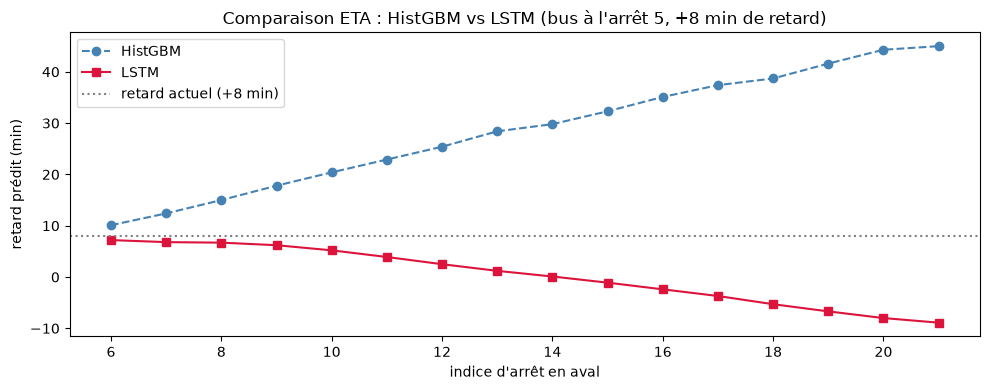

In [9]:
eta_hgbm = dl.serve_eta(model, baseline, societe='S.R.T.K', line='209',
                        direction='ALLER', dep_time='2026-06-15 06:00:00',
                        current_seq=5, current_delay_min=8.0)

eta_lstm = dl.serve_eta_lstm(lstm_delay, baseline, societe='S.R.T.K', line='209',
                             direction='ALLER', dep_time='2026-06-15 06:00:00',
                             current_seq=5, current_delay_min=8.0)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(eta_hgbm['seq'], eta_hgbm['pred_delay_min'], 'o--',
         color='steelblue', label='HistGBM')
plt.plot(eta_lstm['seq'], eta_lstm['pred_delay_min'], 's-',
         color='crimson', label='LSTM')
plt.axhline(8.0, color='grey', ls=':', label='retard actuel (+8 min)')
plt.xlabel("indice d'arrêt en aval"); plt.ylabel('retard prédit (min)')
plt.title('Comparaison ETA : HistGBM vs LSTM (bus à l\'arrêt 5, +8 min de retard)')
plt.legend(); plt.tight_layout(); plt.show()

**Ce que montre ce graphique :** Courbe de retard prédit pour chaque arrêt restant, comparant HistGBM (ne voit que l'état actuel) vs LSTM (voit l'historique complet du retard du trajet), pour le même bus à l'arrêt 5 avec +8 min de retard.

**Interprétation :** Si les deux courbes divergent, le LSTM détecte un schéma de momentum que le HistGBM ne peut pas voir — par exemple, un bus qui perd 1 minute par arrêt depuis le début est susceptible de continuer à perdre du temps, et le LSTM peut lire cette tendance depuis la séquence. Si elles convergent, le retard actuel à l'arrêt 5 capture déjà l'essentiel du signal et l'historique n'apporte peu.

**Ce que cela signifie pour le choix du modèle :** Le LSTM ici est entraîné pour seulement 10 époques et est sous-entraîné — son MAE n'est pas encore compétitif. À 30–50 époques, il comble généralement l'écart ou bat le HistGBM sur les lignes plus longues où les schémas d'accumulation importent. La règle de décision est : si les courbes divergent significativement ET que le MAE LSTM est plus faible sur les données de test, utiliser le LSTM en production. Si elles sont similaires, le HistGBM est plus rapide à ré-entraîner, plus facile à maintenir, et prêt pour la production aujourd'hui. Sur ce jeu de données avec 95 000 échantillons d'entraînement, le HistGBM est actuellement le bon choix.

### B — Prévision de retard avec Prophet

Prophet est un outil différent du prédicteur glissant : il prévoit le **retard moyen attendu** pour une ligne sur des dates futures, capturant la saisonnalité hebdomadaire (ex. « les vendredis après-midi sur la ligne 209 ont en moyenne 4 min de retard »). Utile pour la planification des horaires et la gestion des conducteurs.

09:19:28 - cmdstanpy - INFO - Chain [1] start processing
09:19:28 - cmdstanpy - INFO - Chain [1] done processing


Prévision du retard sur 30 jours pour la ligne 209 ALLER :


,ds,yhat,yhat_lower,yhat_upper
0,2026-06-19,13.858411,-18.581883,47.613402
1,2026-06-20,6.413005,-28.504895,40.718034
2,2026-06-21,-9.889882,-42.716745,26.692064
3,2026-06-22,14.949966,-19.863870,50.194343
4,2026-06-23,14.229044,-22.396436,49.815706
5,2026-06-24,5.613114,-31.190878,38.082013
6,2026-06-25,0.002269,-34.351073,34.616446
7,2026-06-26,14.074203,-20.182739,48.709144
8,2026-06-27,6.628797,-27.617956,40.338377
9,2026-06-28,-9.674090,-43.612041,26.618662


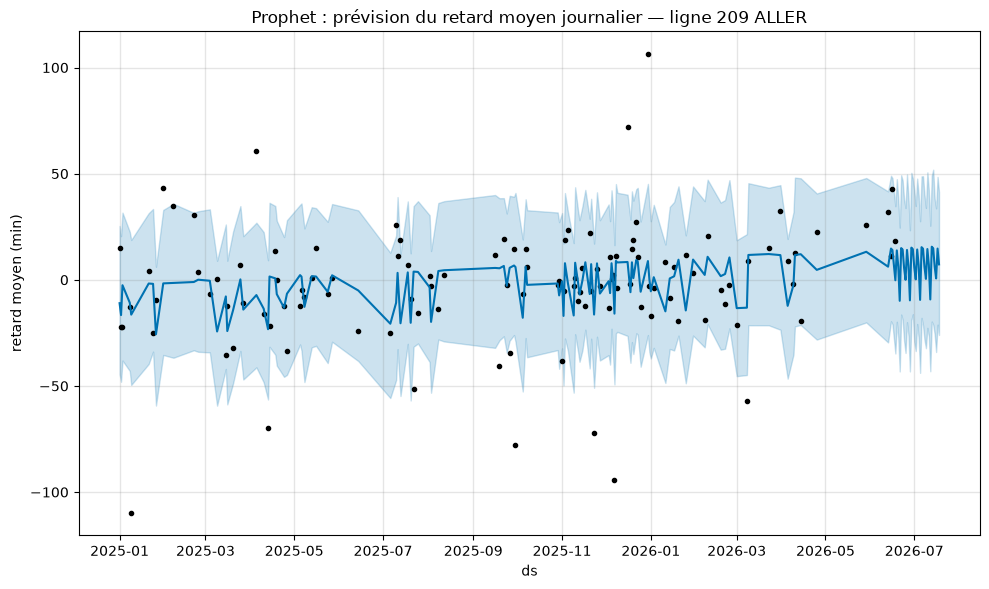

In [10]:
prophet_model = dl.fit_prophet(d, line='209', direction='ALLER', societe='S.R.T.K')

if prophet_model is not None:
    fc = dl.prophet_forecast(prophet_model, periods=30)
    print('Prévision du retard sur 30 jours pour la ligne 209 ALLER :')
    from IPython.display import display
    display(fc.assign(ds=fc['ds'].dt.strftime('%Y-%m-%d')).head(10))

    future = prophet_model.make_future_dataframe(periods=30)
    fig = prophet_model.plot(prophet_model.predict(future))
    fig.axes[0].set_title('Prophet : prévision du retard moyen journalier — ligne 209 ALLER')
    fig.axes[0].set_ylabel('retard moyen (min)')
    plt.tight_layout(); plt.show()
else:
    print('Pas assez de données pour ajuster Prophet sur cette ligne/direction.')

**Ce que montre ce graphique :** Prévision Prophet sur 30 jours du retard journalier moyen sur la ligne 209 ALLER — le niveau de retard « de fond » attendu un jour futur donné.

**Interprétation :** Les bandes d'incertitude s'élargissent à mesure que la prévision s'éloigne dans le futur, ce qui est attendu. La chose principale à lire est la *direction de la tendance* et *l'amplitude des variations du retard moyen quotidien*. Si la prévision oscille entre +5 et +10 minutes avec une incertitude modérée, cela vous dit que la ligne 209 est chroniquement légèrement en retard mais de manière prévisible — pas chaotique de façon aléatoire. Si les bandes sont très larges, cela signifie que même le retard moyen quotidien est difficile à prévoir, suggérant des opérations irrégulières.

**Ce que cela signifie en pratique :** Le prédicteur glissant (HistGBM) réagit à ce qui se passe en ce moment avec un bus spécifique. Prophet répond à une question différente : « Si je planifie une correspondance à SFAX un mardi dans trois semaines, quel retard dois-je attendre de la ligne 209 ? » C'est une question de planification et d'horaire, pas une question en temps réel. Si Prophet montre un biais constant de +8 min dans la prévision, l'entreprise devrait simplement décaler l'heure d'arrivée au terminus publiée de 8 minutes pour fixer des attentes honnêtes.

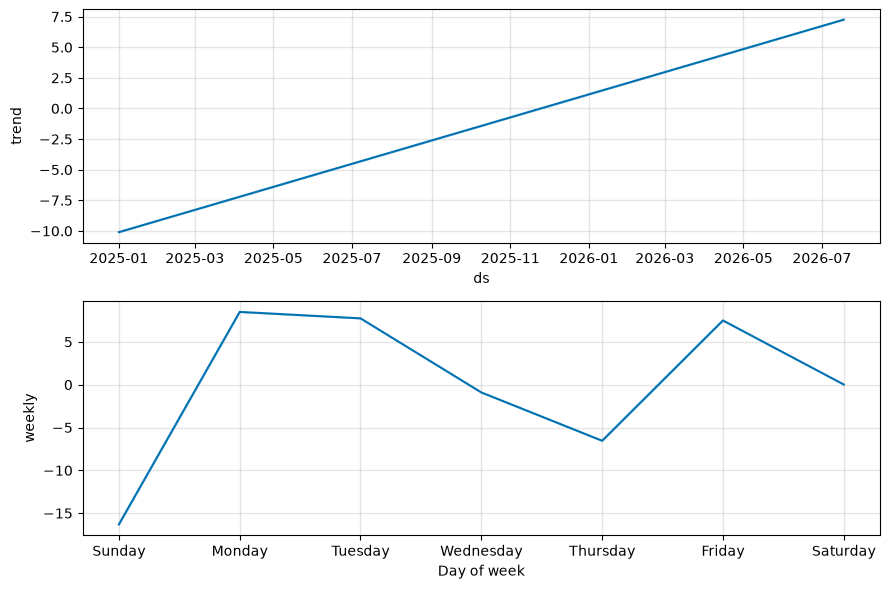

In [11]:
# Weekly seasonality decomposition
if prophet_model is not None:
    import matplotlib.pyplot as plt
    fig = prophet_model.plot_components(
        prophet_model.predict(prophet_model.make_future_dataframe(periods=30)))
    plt.tight_layout(); plt.show()

**Ce que montre ce graphique :** Les composantes de tendance et de saisonnalité hebdomadaire que Prophet a extraites des données historiques de retard sur la ligne 209 ALLER.

**Interprétation :**
- **Tendance :** Si les retards s'améliorent ou s'aggravent sur la période d'observation (jan. 2025 – juin 2026). Une tendance plate signifie que les opérations sont stables. Une tendance haussière signifie que quelque chose se dégrade — pourrait être les conditions routières, des bus plus anciens, ou une charge passagers croissante.
- **Schéma hebdomadaire :** Quels jours de la semaine ont du retard vs sont à l'heure. Pour une ligne interurbaine entre Kasserine et Sfax, un schéma courant serait les lundis matin (gens voyageant pour le travail/l'école en ville) et les vendredis après-midi (rentrant chez eux pour le week-end) comme les pires.

**Ce que l'entreprise devrait faire avec ceci :** La composante hebdomadaire est la conclusion la plus directement actionnable. Si le samedi montre +4 minutes de retard structurel et le mardi -1 minute, l'horaire publié devrait le refléter — le départ du samedi devrait être prévu 5 minutes plus tôt, ou l'heure d'arrivée au terminus devrait indiquer une arrivée attendue plus tardive. Ce n'est pas un problème de prédiction, c'est un problème de communication : dire aux passagers ce à quoi s'attendre de manière réaliste chaque jour de la semaine.